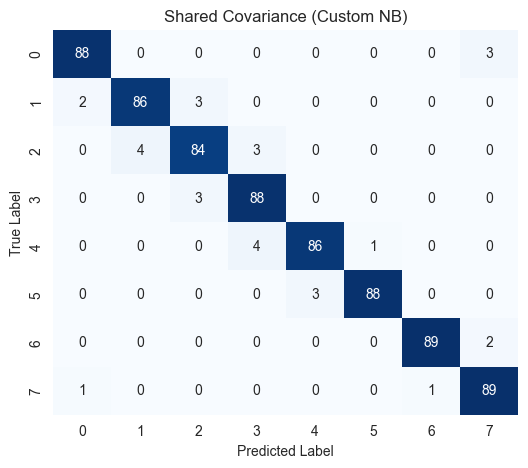

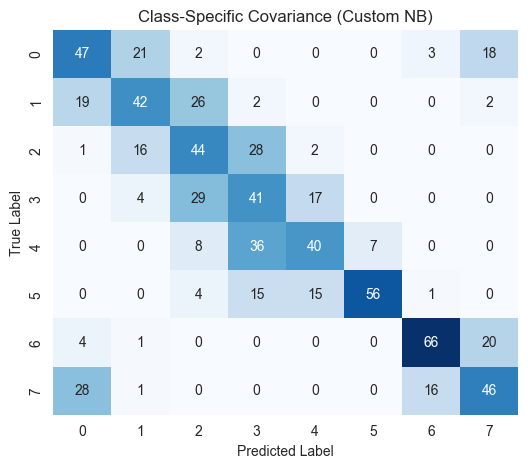

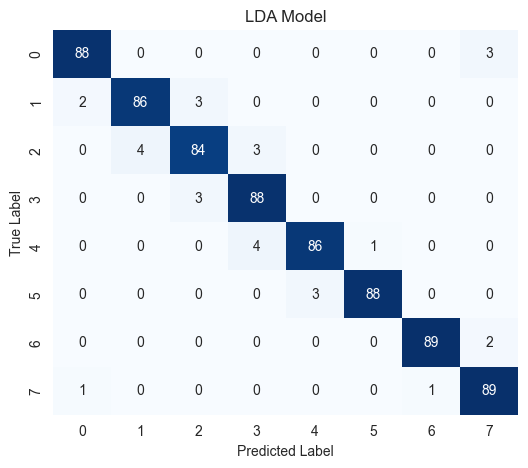

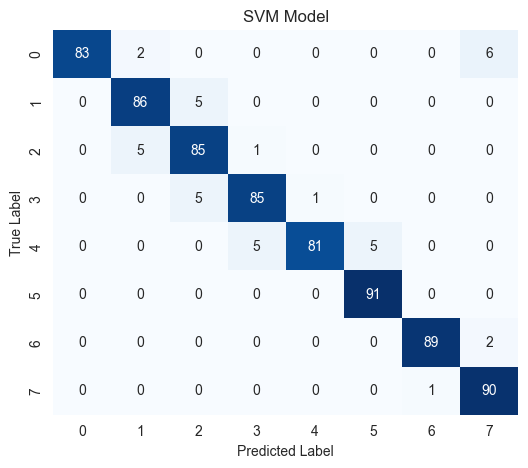

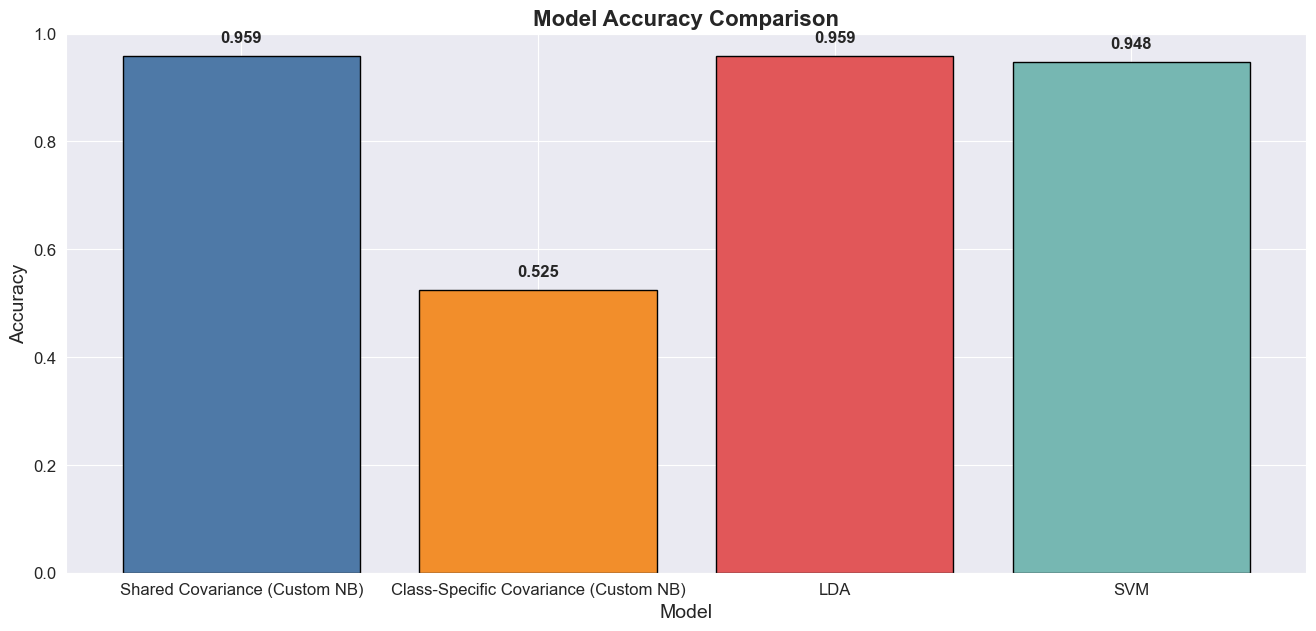

In [8]:
import scipy.io
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
path = 'ps1_realdata.mat'
datamate = scipy.io.loadmat(path)
train = datamate['train_trial']
test = datamate['test_trial']

def extract_spike_counts(trials):
"""提取指定时间窗口内每个到达角度的尖峰计数提取指定时间窗（351-550ms）内每个到达角的尖峰计数。返回形状的特征矩阵（样本数、神经元数*到达角度数）,以及每个样品的标签（到达角度）"""
    spikecounts = []
    labels = []
    for n in range(trials.shape[0]):
        for k in range(trials.shape[1]):
            spike_data = trials[n, k]['spikes'][:, 351:550]
            spikecounts.append(spike_data.sum(axis=1))
            labels.append(k)

    return np.array(spikecounts), np.array(labels)

# 获取训练和测试数据的峰值计数和标签
X_train, y_train = extract_spike_counts(train)
X_test, y_test = extract_spike_counts(test)

# ---朴素贝叶斯分类器（自定义实现）---
class SharedCovarianceNaiveBayes:
    """具有共享协方差的朴素贝叶斯分类器"""
    def __init__(self):
        self.classes = None
        self.mean_vectors = {}
        self.sharedcovariance = None
        self.priors = {}

    def fit(self, X, y):
        """通过计算每个类的均值和共享协方差矩阵来训练模型"""
        self.classes = np.unique(y)
        overallmean = X.mean(axis=0)
        covsum = np.zeros((X.shape[1], X.shape[1]))
        for cls in self.classes:
            X_cls = X[y == cls]
            self.mean_vectors[cls] = X_cls.mean(axis=0)
            covsum += np.cov(X_cls, rowvar=False) * X_cls.shape[0]
            self.priors[cls] = X_cls.shape[0] / X.shape[0]
        self.sharedcovariance = covsum / X.shape[0]

    def predict(self, X):
        """基于共享协方差矩阵预测类"""
        predictions = []
        inv_cov = np.linalg.inv(self.sharedcovariance)
        for x in X:
            classprobs = []
            for cls in self.classes:
                mean = self.mean_vectors[cls]
                prior = self.priors[cls]
                likelihood = -0.5 * (x - mean).T @ inv_cov @ (x - mean)
                posterior = np.log(prior) + likelihood
                classprobs.append(posterior)
            predictions.append(self.classes[np.argmax(classprobs)])
        return np.array(predictions)

class ClassSpecificCovarianceNaiveBayes:
    """具有类特定协方差和正则化的朴素贝叶斯分类器，以避免奇异矩阵"""
    def __init__(self, regularization=1e-6):
        self.classes = None
        self.mean_vectors = {}
        self.cov_matrices = {}
        self.priors = {}
        self.regularization = regularization

    def fit(self, X, y):
        """通过计算平均值、特定类别的协方差矩阵和每个类别的先验概率来训练模型"""
        self.classes = np.unique(y)
        for cls in self.classes:
            X_cls = X[y == cls]
            self.mean_vectors[cls] = X_cls.mean(axis=0)
            cov_matrix = np.cov(X_cls, rowvar=False) + self.regularization * np.eye(X_cls.shape[1])
            self.cov_matrices[cls] = cov_matrix
            self.priors[cls] = X_cls.shape[0] / X.shape[0]

    def predict(self, X):
        """基于特定类别的协方差矩阵预测类别"""
        predictions = []
        for x in X:
            class_probs = []
            for cls in self.classes:
                mean = self.mean_vectors[cls]
                cov = self.cov_matrices[cls]
                prior = self.priors[cls]
                inv_cov = np.linalg.inv(cov)
                likelihood = (x - mean).T @ inv_cov @ (x - mean) * (-0.5) + np.log(np.linalg.det(cov)) * (-0.5)
                posterior = np.log(prior) + likelihood
                class_probs.append(posterior)
            predictions.append(self.classes[np.argmax(class_probs)])
        return np.array(predictions)

# 训练和评估自定义朴素贝叶斯模型
shared_cov_model_custom = SharedCovarianceNaiveBayes()
shared_cov_model_custom.fit(X_train, y_train)
y_pred_shared_custom = shared_cov_model_custom.predict(X_test)
accuracy_shared_custom = accuracy_score(y_test, y_pred_shared_custom)

class_specific_model_custom = ClassSpecificCovarianceNaiveBayes(regularization=1e-3)
class_specific_model_custom.fit(X_train, y_train)
y_pred_class_specific_custom = class_specific_model_custom.predict(X_test)
accuracy_class_specific_custom = accuracy_score(y_test, y_pred_class_specific_custom)

# ---LDA和SVM分类器---
# 训练和评估LDA模型
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)
y_pred_lda = lda_model.predict(X_test)
accuracy_lda = accuracy_score(y_test, y_pred_lda)

# 训练和评估SVM模型
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# ---混淆矩阵与精度比较---
# 定义一个函数来绘制混淆矩阵
def plot_confusion_matrix(cm, title):
    """Plots a heatmap of the confusion matrix."""
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# 获取每个模型的混淆矩阵
cm_shared_custom = confusion_matrix(y_test, y_pred_shared_custom)
cm_class_specific_custom = confusion_matrix(y_test, y_pred_class_specific_custom)
cm_lda = confusion_matrix(y_test, y_pred_lda)
cm_svm = confusion_matrix(y_test, y_pred_svm)

# 绘制混淆矩阵
plot_confusion_matrix(cm_shared_custom, "Shared Covariance (Custom NB)")
plot_confusion_matrix(cm_class_specific_custom, "Class-Specific Covariance (Custom NB)")
plot_confusion_matrix(cm_lda, "LDA Model")
plot_confusion_matrix(cm_svm, "SVM Model")

# 比较不同模型的精度
models = ['Shared Covariance (Custom NB)', 'Class-Specific Covariance (Custom NB)', 'LDA', 'SVM']
accuracies = [accuracy_shared_custom, accuracy_class_specific_custom, accuracy_lda, accuracy_svm]
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

plt.figure(figsize=(16, 7))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()